In [118]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from networkx.algorithms import community


In [119]:
# =============================================================================
# Definições Gerais
# =============================================================================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
DIR_IMAGEM = "C:\\Users\\alexa\\Atividades\\LocalGrafos\\Output\\Book\\Exploração de Dados\\"


In [120]:
# =============================================================================
# 1. CRIAÇÃO E INFORMAÇÕES BÁSICAS DO GRAFO
# =============================================================================
G = nx.karate_club_graph()
print ("# =============================================================================")
print ("# INFORMAÇÕES BÁSICAS DO GRAFO")
print ("# =============================================================================")
print (f"# Número de nós ......: {G.number_of_nodes()}")
print (f"# Número de arestas ..: {G.number_of_edges()}")
print (f"# Densidade do grafo .: {nx.density(G):.4f}")
print (f"# É conexo? ..........: {nx.is_connected(G)}")
print (f"# É direcionado? .....: {G.is_directed()}")
print ("# =============================================================================")


# =============================================================================
# INFORMAÇÕES BÁSICAS DO GRAFO
# =============================================================================
# Número de nós ......: 34
# Número de arestas ..: 78
# Densidade do grafo .: 0.1390
# É conexo? ..........: True
# É direcionado? .....: False
# =============================================================================


In [121]:
# =============================================================================
# Calcular métricas
# =============================================================================
betweenness = nx.betweenness_centrality(G)
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
pagerank = nx.pagerank(G)
clustering = nx.clustering(G)

degrees = [d for n, d in G.degree()]
degree_dict = dict(G.degree())



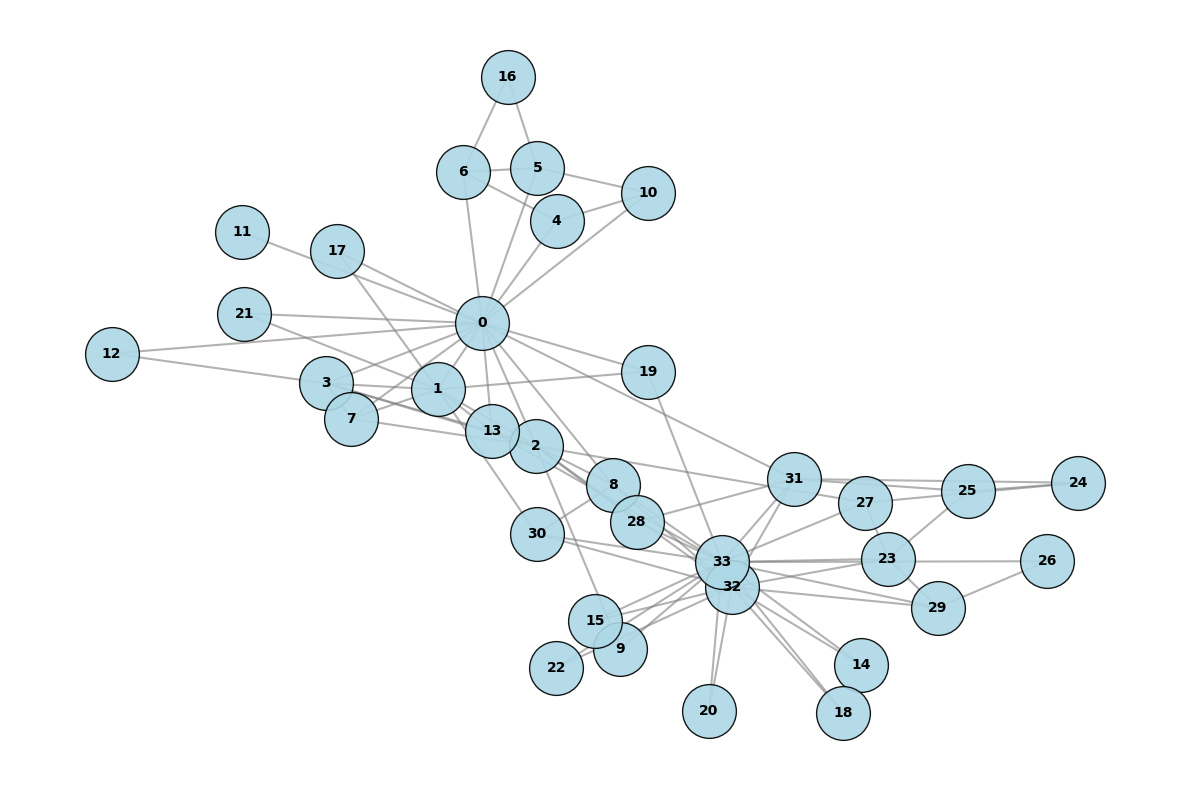

In [122]:
# =============================================================================
# 2. GRÁFICO 1: GRAFO ORIGINAL
# =============================================================================
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes (
    G, 
    pos, 
    node_size=1500, 
    node_color='lightblue', 
    alpha=0.9, 
    edgecolors='black', 
    linewidths=1
    )

nx.draw_networkx_edges (
    G, 
    pos, 
    alpha=0.6, 
    edge_color='gray', 
    width=1.5
    )

nx.draw_networkx_labels (
    G, 
    pos, 
    font_size=10, 
    font_weight='bold'
    )

#plt.title("Grafo Original - Rede Social do Clube de Karatê", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "GrafoBase.png", format="PNG")
plt.show()


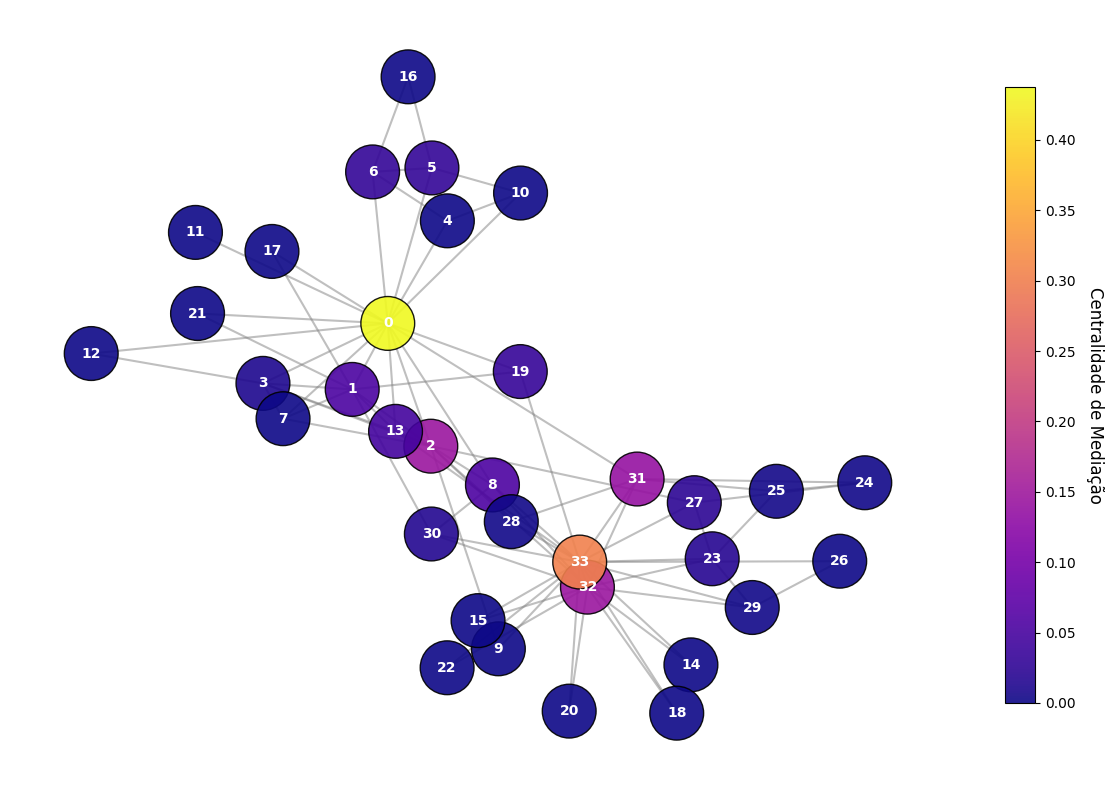

In [123]:
# =============================================================================
# 3. GRÁFICO 2: CENTRALIDADE DE BETWEENNESS
# =============================================================================
plt.figure(figsize=(12, 8))
node_colors = list(betweenness.values())

nodes = nx.draw_networkx_nodes(
    G, 
    pos, 
    node_size=1500, 
    node_color=node_colors, 
    cmap=plt.cm.plasma, 
    alpha=0.9,
    edgecolors='black', 
    linewidths=1
    )

nx.draw_networkx_edges (
    G, 
    pos, 
    alpha=0.5, 
    edge_color='gray', 
    width=1.5
    )

nx.draw_networkx_labels (
    G, 
    pos, 
    font_color="white",
    font_size=10, 
    font_weight='bold'
    )

cbar = plt.colorbar(nodes, shrink=0.8)
cbar.set_label('Centralidade de Mediação', rotation=270, labelpad=20, fontsize=12)

#plt.title("Grafo - Colorido por Centralidade de Mediação", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "CentralidadeMediacao.png", format="PNG")
plt.show()


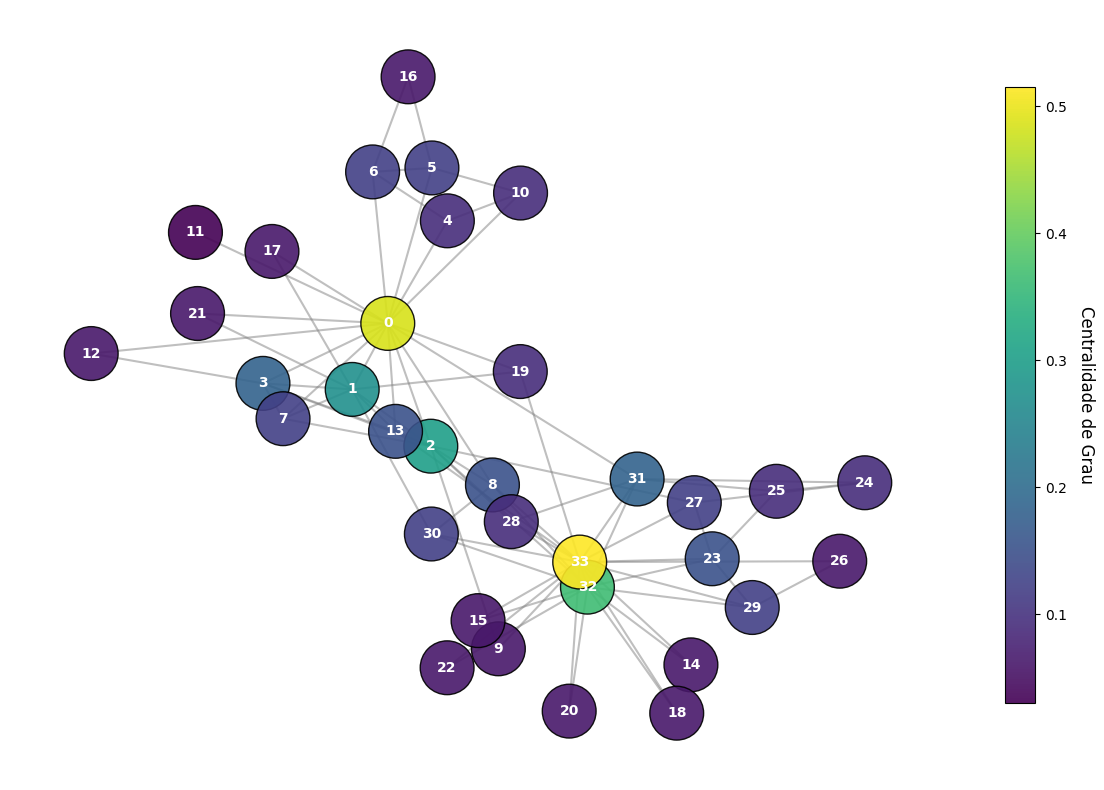

In [124]:
# =============================================================================
# 4. GRÁFICO 3: CENTRALIDADE DE GRAU
# =============================================================================
plt.figure(figsize=(12, 8))
node_colors = list(degree_centrality.values())

nodes = nx.draw_networkx_nodes (
    G, 
    pos, 
    node_size=1500, 
    node_color=node_colors, 
    cmap=plt.cm.viridis, 
    alpha=0.9,
    edgecolors='black', 
    linewidths=1
    )

nx.draw_networkx_edges (
    G, 
    pos, 
    alpha=0.5, 
    edge_color='gray', 
    width=1.5
    )

nx.draw_networkx_labels (
    G, 
    pos, 
    font_size=10, 
    font_color="white",
    font_weight='bold'
    )

cbar = plt.colorbar(nodes, shrink=0.8)
cbar.set_label('Centralidade de Grau', rotation=270, labelpad=20, fontsize=12)

plt.axis('off')
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "CentralidadeGrau.png", format="PNG")
plt.show()

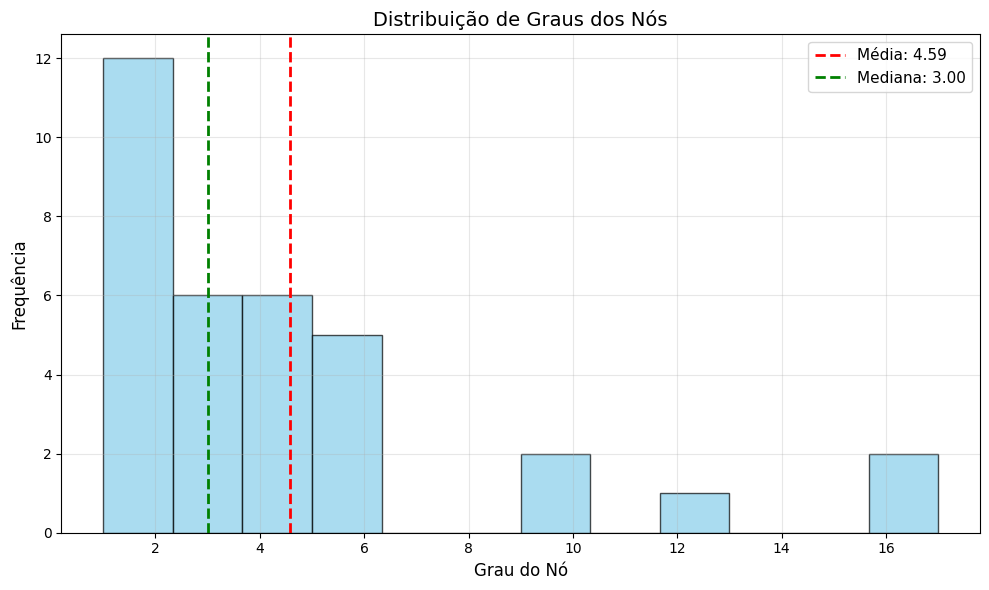

In [125]:
# =============================================================================
# 5. GRÁFICO 4: DISTRIBUIÇÃO DE GRAUS - HISTOGRAMA
# =============================================================================
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist (
    degrees, 
    bins=12, 
    edgecolor='black', 
    alpha=0.7, 
    color='skyblue', 
    density=False
    )

plt.xlabel("Grau do Nó", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.title("Distribuição de Graus dos Nós", fontsize=14)
plt.grid(True, alpha=0.3)

plt.axvline (
    np.mean(degrees), 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label=f'Média: {np.mean(degrees):.2f}'
    )

plt.axvline (
    np.median(degrees), 
    color='green', 
    linestyle='--', 
    linewidth=2,
    label=f'Mediana: {np.median(degrees):.2f}'
    )

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "DistribuicaoGrausNos.png", format="PNG")
plt.show()


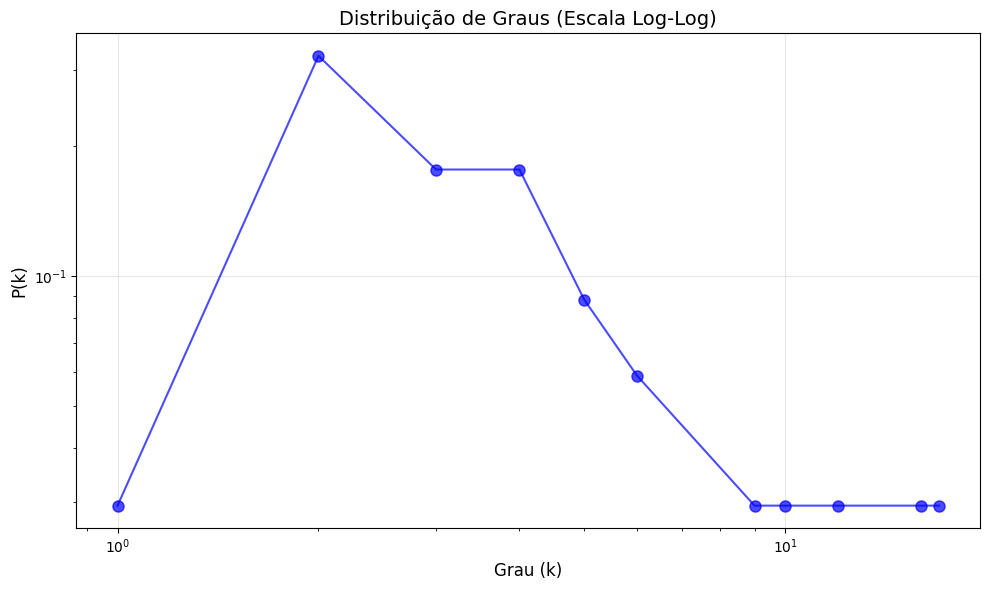

In [126]:
# =============================================================================
# 6. GRÁFICO 5: DISTRIBUIÇÃO DE GRAUS - LOG-LOG
# =============================================================================
plt.figure(figsize=(10, 6))
degree_counts = np.bincount(degrees)
nonzero_indices = np.where(degree_counts > 0)[0]
nonzero_counts = degree_counts[nonzero_indices]

plt.loglog (nonzero_indices, nonzero_counts / len(degrees), 'bo-', alpha=0.7, markersize=8)
plt.xlabel ("Grau (k)", fontsize=12)
plt.ylabel ("P(k)", fontsize=12)

plt.title ("Distribuição de Graus (Escala Log-Log)", fontsize=14)
plt.grid (True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "DistribuicaoGrausLogLog.png", format="PNG")
plt.show()


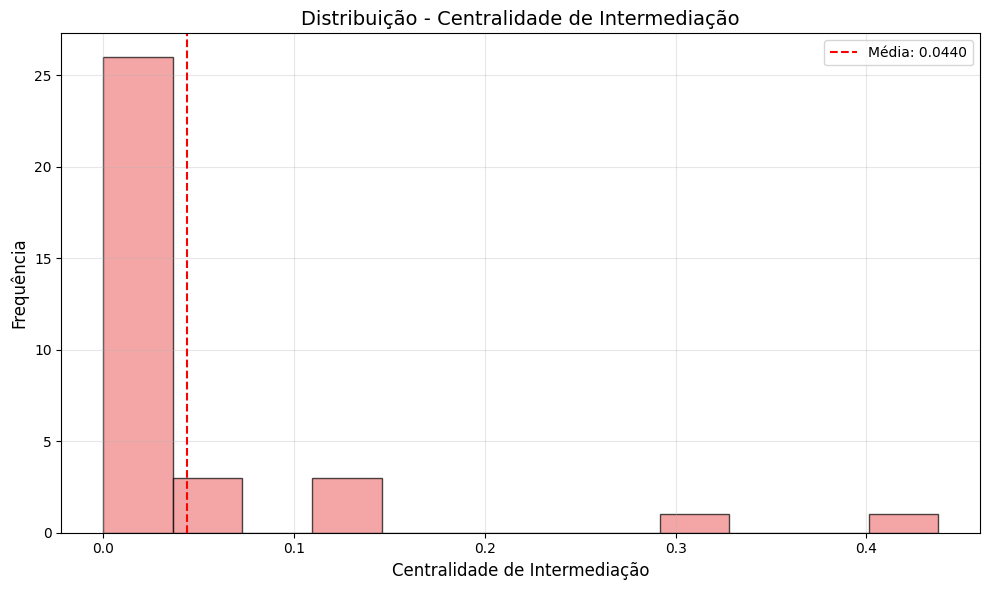

In [127]:
# =============================================================================
# 7. GRÁFICO 6: DISTRIBUIÇÃO DE BETWEENNESS
# =============================================================================
plt.figure(figsize=(10, 6))
plt.hist (
    betweenness.values(), 
    bins=12, 
    edgecolor='black', 
    alpha=0.7, 
    color='lightcoral'
    )

plt.xlabel('Centralidade de Intermediação', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição - Centralidade de Intermediação', fontsize=14)
plt.grid(True, alpha=0.3)

plt.axvline (
    np.mean(list(betweenness.values())), 
    color='red', 
    linestyle='--', 
    label=f'Média: {np.mean(list(betweenness.values())):.4f}'
    )

plt.legend()
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "DistribuicaoCentralidadeIntermediacao.png", format="PNG")
plt.show()

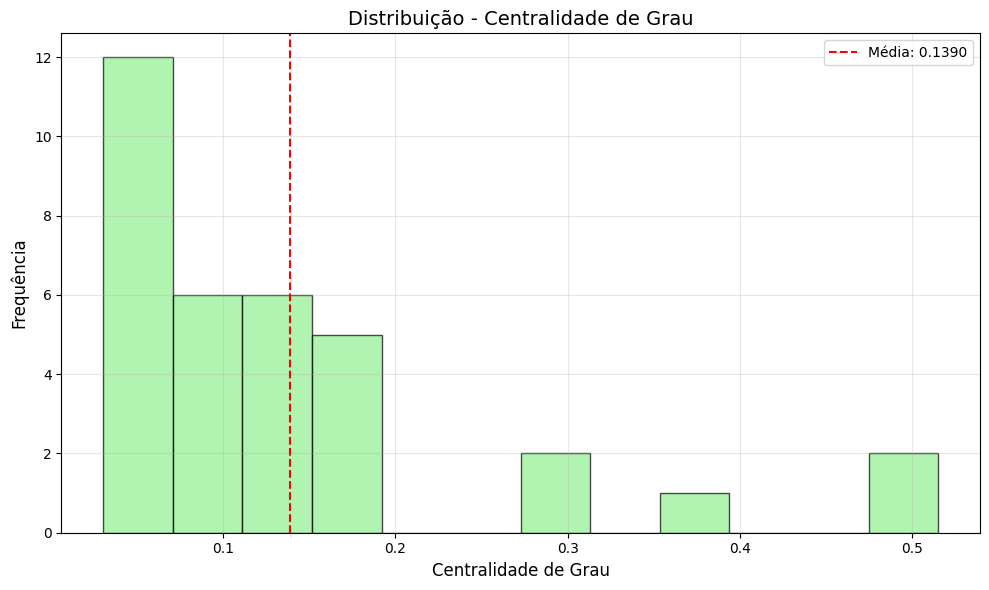

In [128]:
# =============================================================================
# 8. GRÁFICO 7: DISTRIBUIÇÃO DE DEGREE CENTRALITY
# =============================================================================
plt.figure(figsize=(10, 6))
plt.hist (
    degree_centrality.values(), 
    bins=12, 
    edgecolor='black', 
    alpha=0.7, 
    color='lightgreen'
    )

plt.xlabel('Centralidade de Grau', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição - Centralidade de Grau', fontsize=14)
plt.grid(True, alpha=0.3)

plt.axvline (
    np.mean(list(degree_centrality.values())), 
    color='red', 
    linestyle='--',
    label=f'Média: {np.mean(list(degree_centrality.values())):.4f}'
    )

plt.legend()
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "DistribuicaoCentralidadeGrau.png", format="PNG")
plt.show()

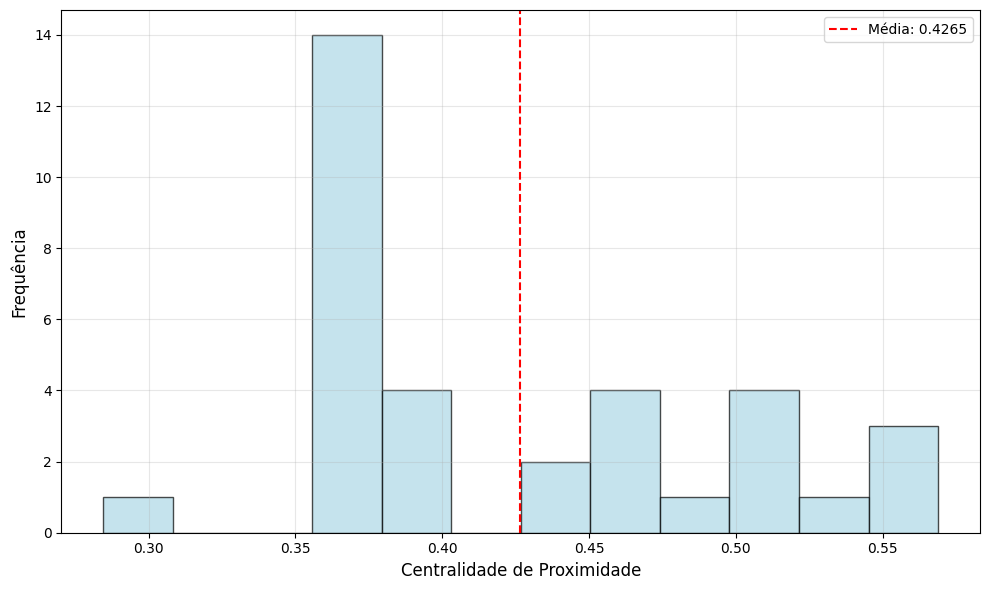

In [129]:
# =============================================================================
# 9. GRÁFICO 8: DISTRIBUIÇÃO DE CLOSENESS CENTRALITY
# =============================================================================
plt.figure(figsize=(10, 6))
plt.hist (
    closeness_centrality.values(), 
    bins=12, 
    edgecolor='black', 
    alpha=0.7, 
    color='lightblue'
    )

plt.xlabel('Centralidade de Proximidade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
#plt.title('Distribuição - Centralidade de Proximidade', fontsize=14)
plt.grid(True, alpha=0.3)

plt.axvline (
    np.mean(list(closeness_centrality.values())), 
    color='red', 
    linestyle='--',
    label=f'Média: {np.mean(list(closeness_centrality.values())):.4f}'
    )

plt.legend()
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "DistribuicaoCentralidadeProximidade.png", format="PNG")
plt.show()

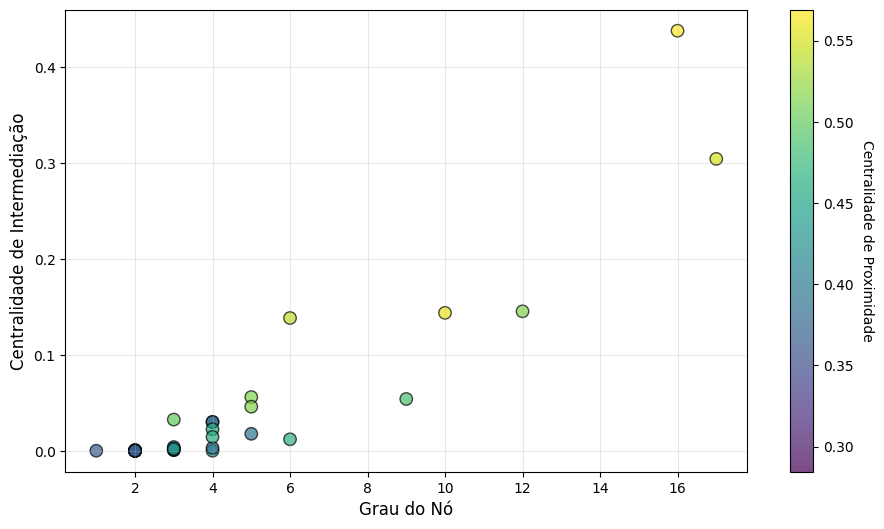

In [130]:
# =============================================================================
# 10. GRÁFICO 9: RELAÇÃO GRAU VS BETWEENNESS
# =============================================================================
plt.figure(figsize=(11, 6))
degrees_list = list(degree_dict.values())
betweenness_list = list(betweenness.values())

scatter = plt.scatter (
    degrees_list, 
    betweenness_list, 
    alpha=0.7, 
    c=closeness_centrality.values(), 
    cmap='viridis', 
    s=80, 
    edgecolors='black'
    )

plt.xlabel('Grau do Nó', fontsize=12)
plt.ylabel('Centralidade de Intermediação', fontsize=12)
#plt.title('Relação: Grau vs Betweenness (cor = Closeness)', fontsize=14)
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Centralidade de Proximidade', rotation=270, labelpad=15)

plt.savefig(DIR_IMAGEM + "GrauXProximidade.png", format="PNG")
plt.show()



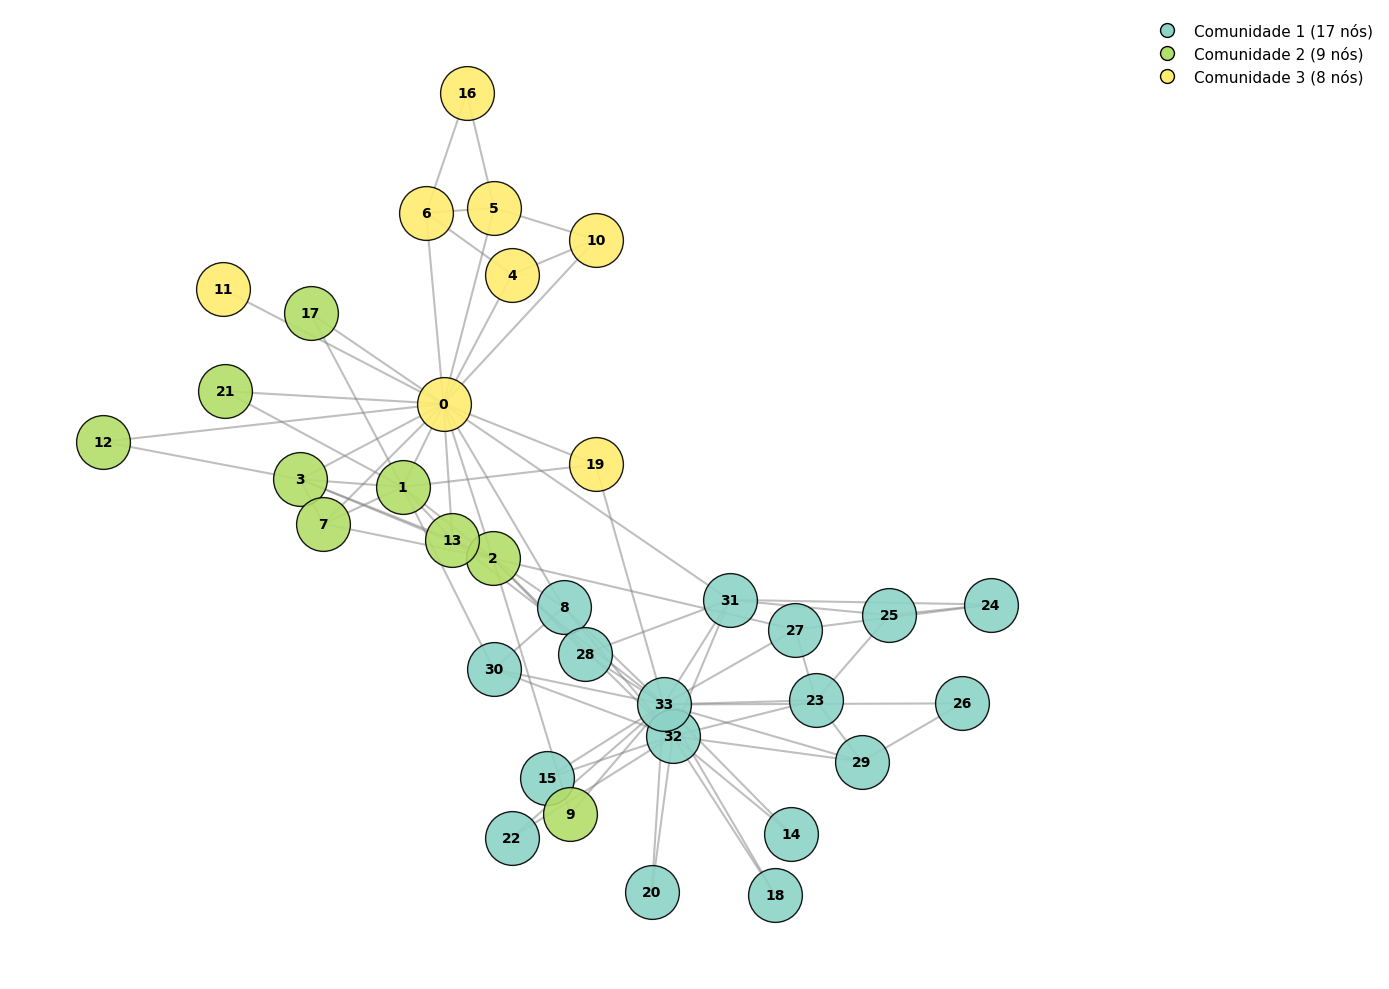

In [131]:
# =============================================================================
# 11. Comunidade 
# =============================================================================
communities = list(community.greedy_modularity_communities(G))
plt.figure(figsize=(14, 10))
colors = plt.cm.Set3(np.linspace(0, 1, len(communities)))

for i, com in enumerate(communities):
    nx.draw_networkx_nodes(
        G, 
        pos, 
        nodelist=list(com), 
        node_size=1500, 
        node_color=[colors[i]], 
        alpha=0.9, 
        edgecolors='black', 
        linewidths=1
    )

nx.draw_networkx_edges(
    G, 
    pos, 
    alpha=0.5, 
    edge_color='gray', 
    width=1.5
)

nx.draw_networkx_labels(
    G, 
    pos, 
    font_size=10, 
    font_weight='bold'
)

# Criar legenda personalizada com círculos (sem retângulos)
import matplotlib.lines as mlines

legend_elements = []
for i, com in enumerate(communities):
    legend_elements.append(
        mlines.Line2D([], [],
                      marker='o',
                      color='w',  # Cor da linha (branca - invisível)
                      markerfacecolor=colors[i],
                      markeredgecolor='black',
                      markersize=10,  # Tamanho do círculo na legenda
                      linestyle='None',  # Sem linha
                      label=f'Comunidade {i+1} ({len(com)} nós)')
    )
  
plt.legend(handles=legend_elements, 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left', 
           fontsize=11,
           frameon=False)   

plt.axis('off')
plt.tight_layout()
plt.savefig(DIR_IMAGEM + "IdentificacaoComunidades.png", format="PNG")
plt.show()


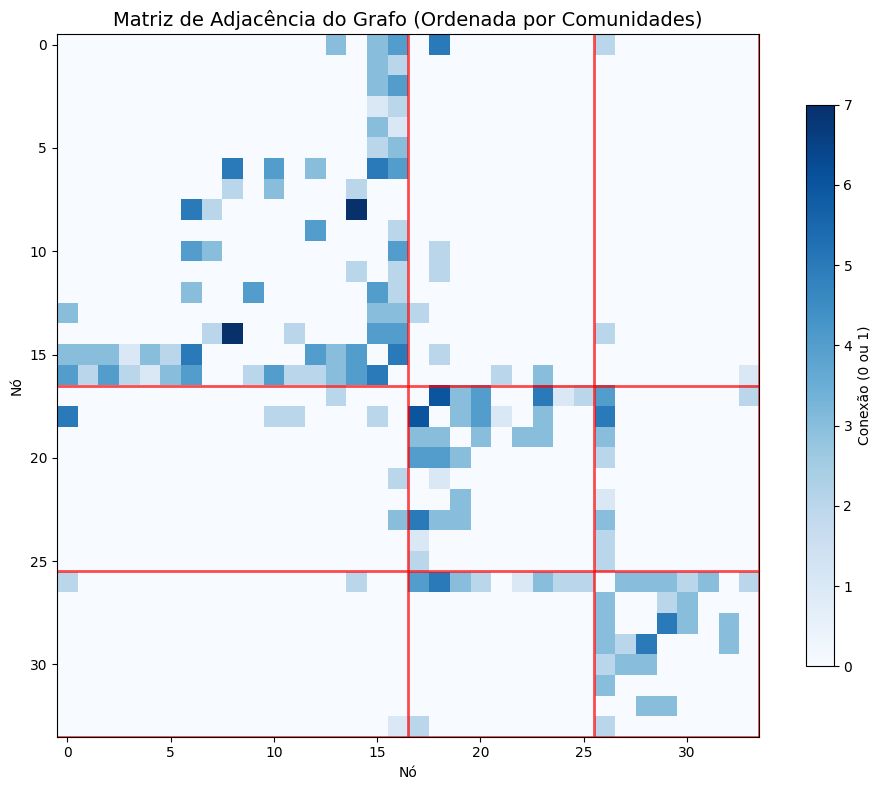

In [132]:
# =============================================================================
# 12. GRÁFICO 11: MATRIZ DE ADJACÊNCIA
# =============================================================================
plt.figure(figsize=(10, 8))

node_order = []
for com in communities:
    node_order.extend(sorted(com))
    
adj_matrix_ordered = nx.to_numpy_array(G, nodelist=node_order)
plt.imshow(adj_matrix_ordered, cmap='Blues', interpolation='none')
plt.colorbar(label='Conexão (0 ou 1)', shrink=0.8)

plt.title('Matriz de Adjacência do Grafo (Ordenada por Comunidades)', fontsize=14)
plt.xlabel('Nó')
plt.ylabel('Nó')

current_idx = 0
for com in communities:
    current_idx += len(com)
    plt.axhline (
        y=current_idx - 0.5, 
        color='red', 
        linestyle='-', 
        alpha=0.7, 
        linewidth=2
        )
    
    plt.axvline (
        x=current_idx - 0.5, 
        color='red', 
        linestyle='-', 
        alpha=0.7, 
        linewidth=2
        )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "MatrizAdjacenciaComunidades.png", format="PNG")
plt.show ()


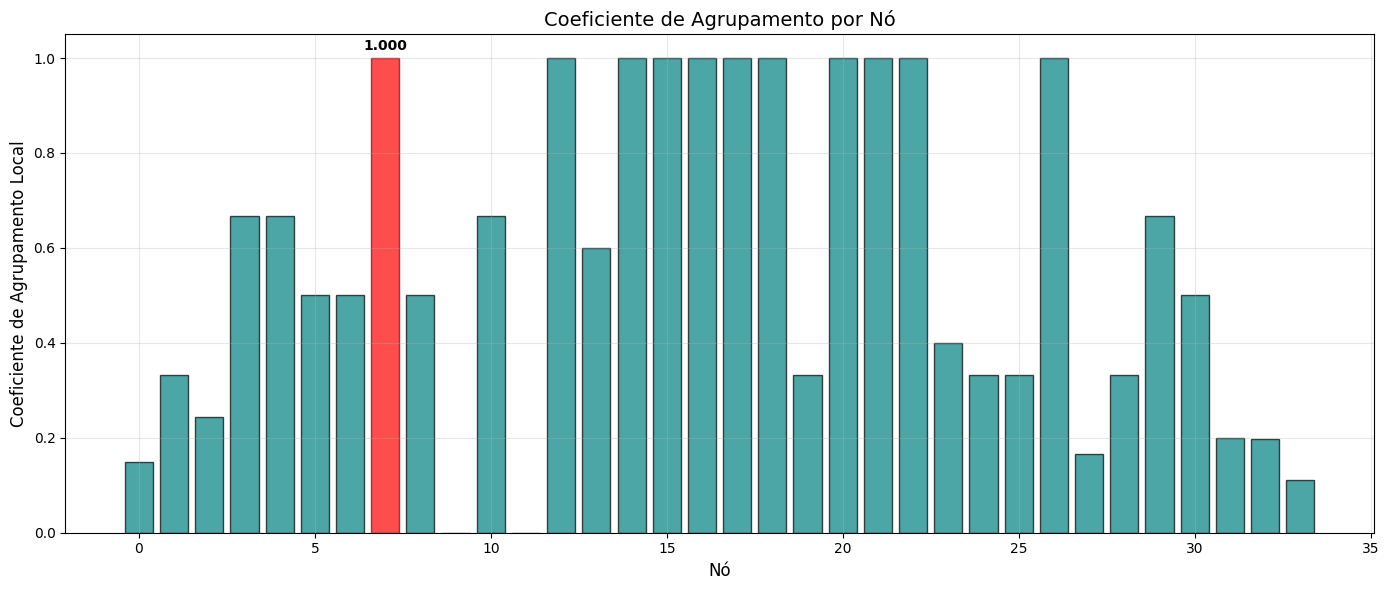

In [133]:
# =============================================================================
# 13. GRÁFICO 12: COEFICIENTE DE AGRUPAMENTO POR NÓ
# =============================================================================
plt.figure(figsize=(14, 6))
nodes = list(clustering.keys())
values = list(clustering.values())

bars = plt.bar(nodes, values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Nó', fontsize=12)
plt.ylabel('Coeficiente de Agrupamento Local', fontsize=12)
plt.title('Coeficiente de Agrupamento por Nó', fontsize=14)
plt.grid(True, alpha=0.3)

max_cluster_node = max(clustering, key=clustering.get)
max_index = list(clustering.keys()).index(max_cluster_node)
bars[max_index].set_color('red')
bars[max_index].set_edgecolor('darkred')

plt.text (
    max_index, 
    values[max_index] + 0.01, 
    f'{values[max_index]:.3f}', 
    ha='center', 
    va='bottom', 
    fontweight='bold', 
    fontsize=10
    )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "CoeficienteAgrupamento.png", format="PNG")
plt.show ()


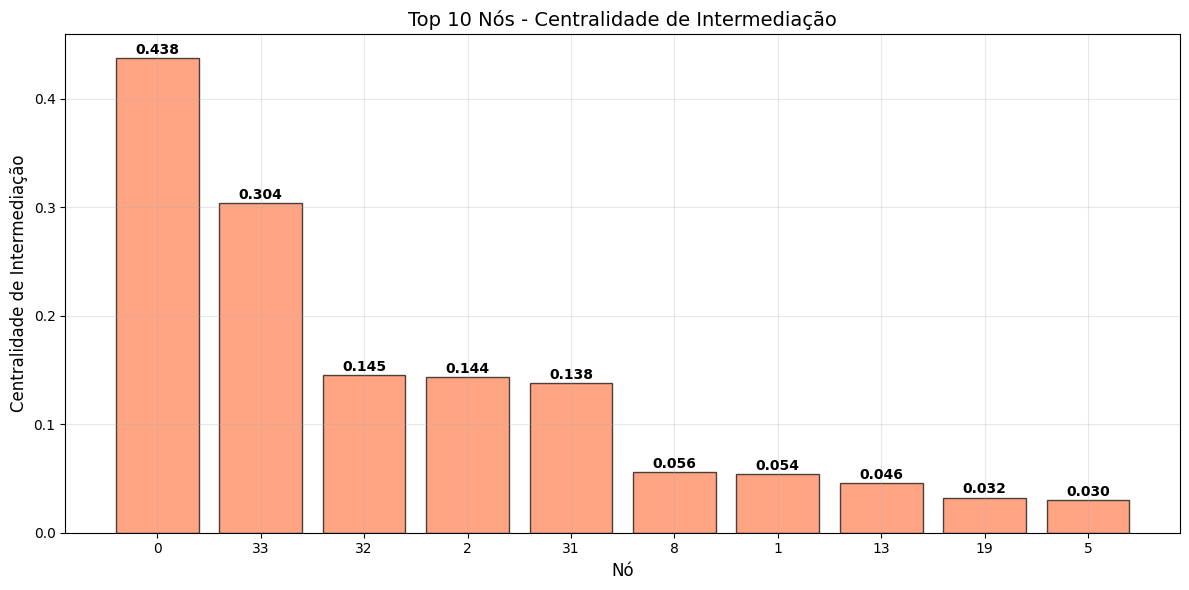

In [134]:
# =============================================================================
# 14. GRÁFICO 13: TOP 10 NÓS - BETWEENNESS
# =============================================================================
plt.figure(figsize=(12, 6))
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
nodes_b, values_b = zip(*top_betweenness)

bars = plt.bar (
    range(len(nodes_b)), 
    values_b, 
    color='coral', 
    alpha=0.7, 
    edgecolor='black'
    )

plt.xlabel('Nó', fontsize=12)
plt.ylabel('Centralidade de Intermediação', fontsize=12)
plt.title('Top 10 Nós - Centralidade de Intermediação', fontsize=14)
plt.xticks(range(len(nodes_b)), nodes_b)
plt.grid(True, alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, values_b)):
    plt.text (
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.001, 
        f'{value:.3f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
        )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "Top10NosCentralidadeIntermediacao.png", format="PNG")
plt.show ()


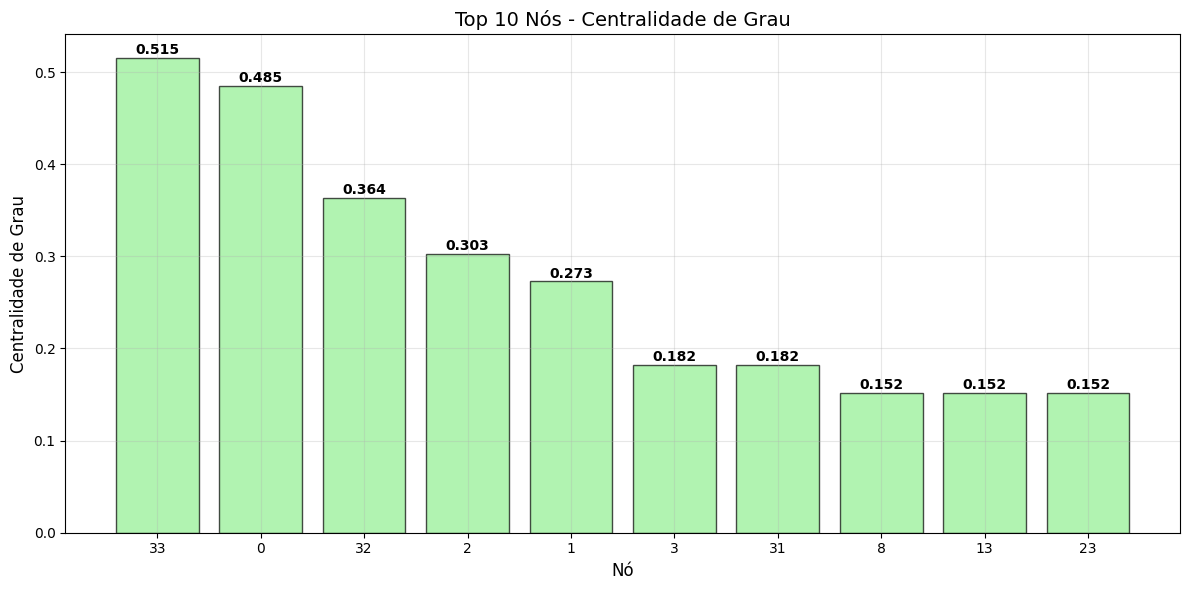

In [135]:
# =============================================================================
# 15. GRÁFICO 14: TOP 10 NÓS - DEGREE CENTRALITY
# =============================================================================
plt.figure(figsize=(12, 6))
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
nodes_d, values_d = zip(*top_degree)

bars = plt.bar (
    range(len(nodes_d)), 
    values_d, 
    color='lightgreen', 
    alpha=0.7, 
    edgecolor='black'
    )

plt.xlabel('Nó', fontsize=12)
plt.ylabel('Centralidade de Grau', fontsize=12)
plt.title('Top 10 Nós - Centralidade de Grau', fontsize=14)
plt.xticks(range(len(nodes_d)), nodes_d)
plt.grid(True, alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, values_d)):
    plt.text (
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.001, 
        f'{value:.3f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
        )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "Top10CentralidadeGrau.png", format="PNG")
plt.show ()



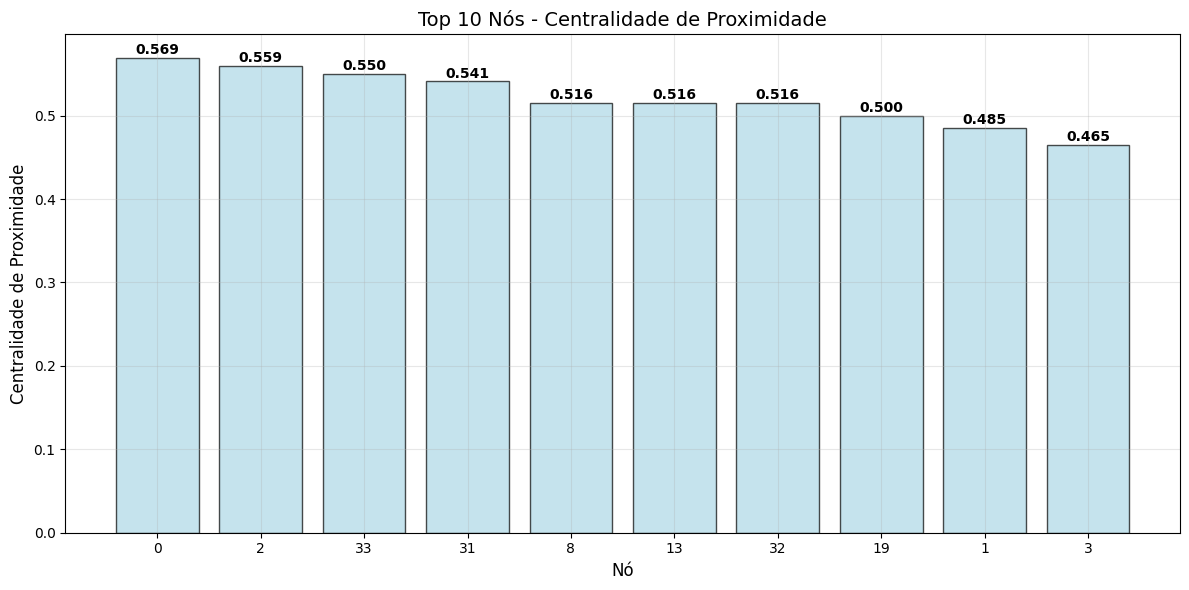

In [136]:
# =============================================================================
# 16. GRÁFICO 15: TOP 10 NÓS - CLOSENESS
# =============================================================================
plt.figure(figsize=(12, 6))
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
nodes_c, values_c = zip(*top_closeness)

bars = plt.bar (
    range( 
        len(nodes_c)), 
        values_c, 
        color='lightblue', 
        alpha=0.7, 
        edgecolor='black'
    )

plt.xlabel('Nó', fontsize=12)
plt.ylabel('Centralidade de Proximidade', fontsize=12)
plt.title('Top 10 Nós - Centralidade de Proximidade', fontsize=14)
plt.xticks(range(len(nodes_c)), nodes_c)
plt.grid(True, alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, values_c)):
    plt.text (
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.001, 
        f'{value:.3f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
        )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "Top10CentralidadeProximidade.png", format="PNG")
plt.show ()


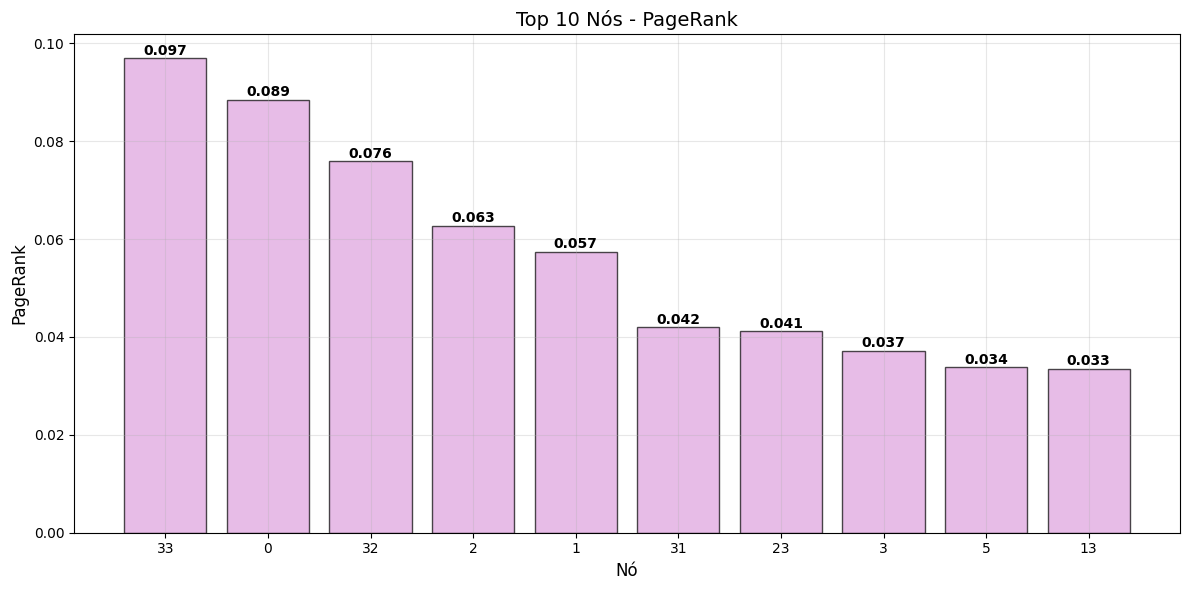

In [137]:
# =============================================================================
# 17. GRÁFICO 16: TOP 10 NÓS - PAGERANK
# =============================================================================
plt.figure(figsize=(12, 6))
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
nodes_p, values_p = zip(*top_pagerank)

bars = plt.bar (
    range(len(nodes_p)), 
    values_p, 
    color='plum', 
    alpha=0.7, 
    edgecolor='black'
    )

plt.xlabel('Nó', fontsize=12)
plt.ylabel('PageRank', fontsize=12)
plt.title('Top 10 Nós - PageRank', fontsize=14)
plt.xticks(range(len(nodes_p)), nodes_p)
plt.grid(True, alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, values_p)):
    plt.text (
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.0001, 
        f'{value:.3f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
        )


plt.tight_layout()
plt.savefig(DIR_IMAGEM + "Top10Pagerank.png", format="PNG")
plt.show ()


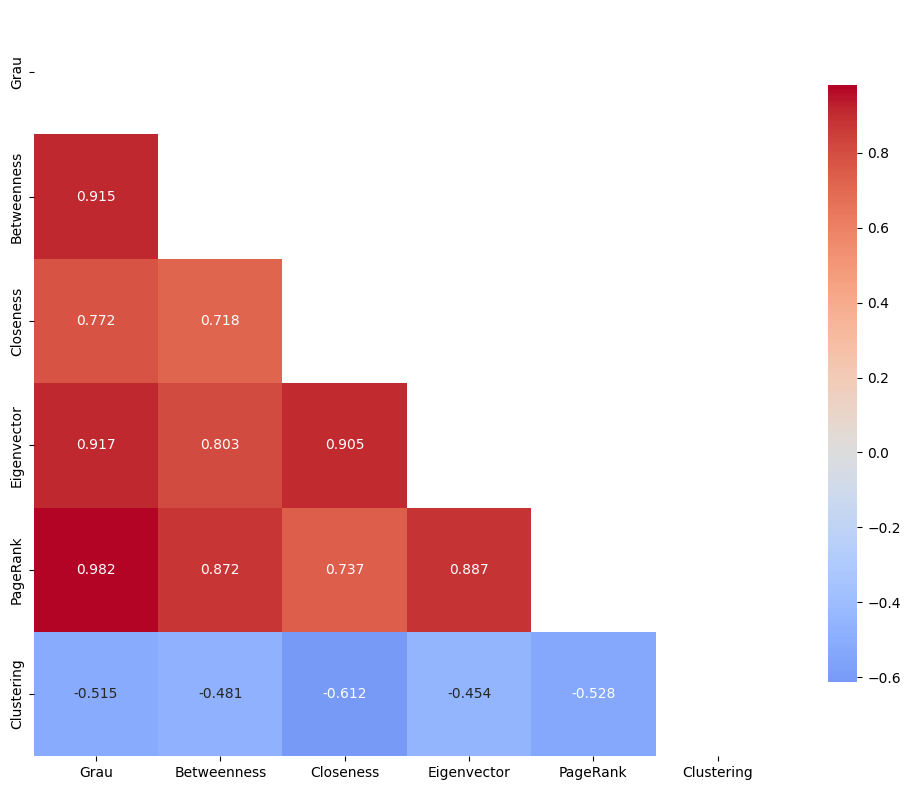

In [138]:
# =============================================================================
# 18. GRÁFICO 17: MATRIZ DE CORRELAÇÃO
# =============================================================================
metrics_data = {
    'Grau': list(degree_dict.values()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness_centrality.values()),
    'Eigenvector': list(eigenvector_centrality.values()),
    'PageRank': list(pagerank.values()),
    'Clustering': list(clustering.values())
}

df_metrics = pd.DataFrame(metrics_data)
correlation_matrix = df_metrics.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap (
    correlation_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    fmt='.3f', 
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 10}
    )

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "MatrizCorrelacao.png", format="PNG")
plt.show ()


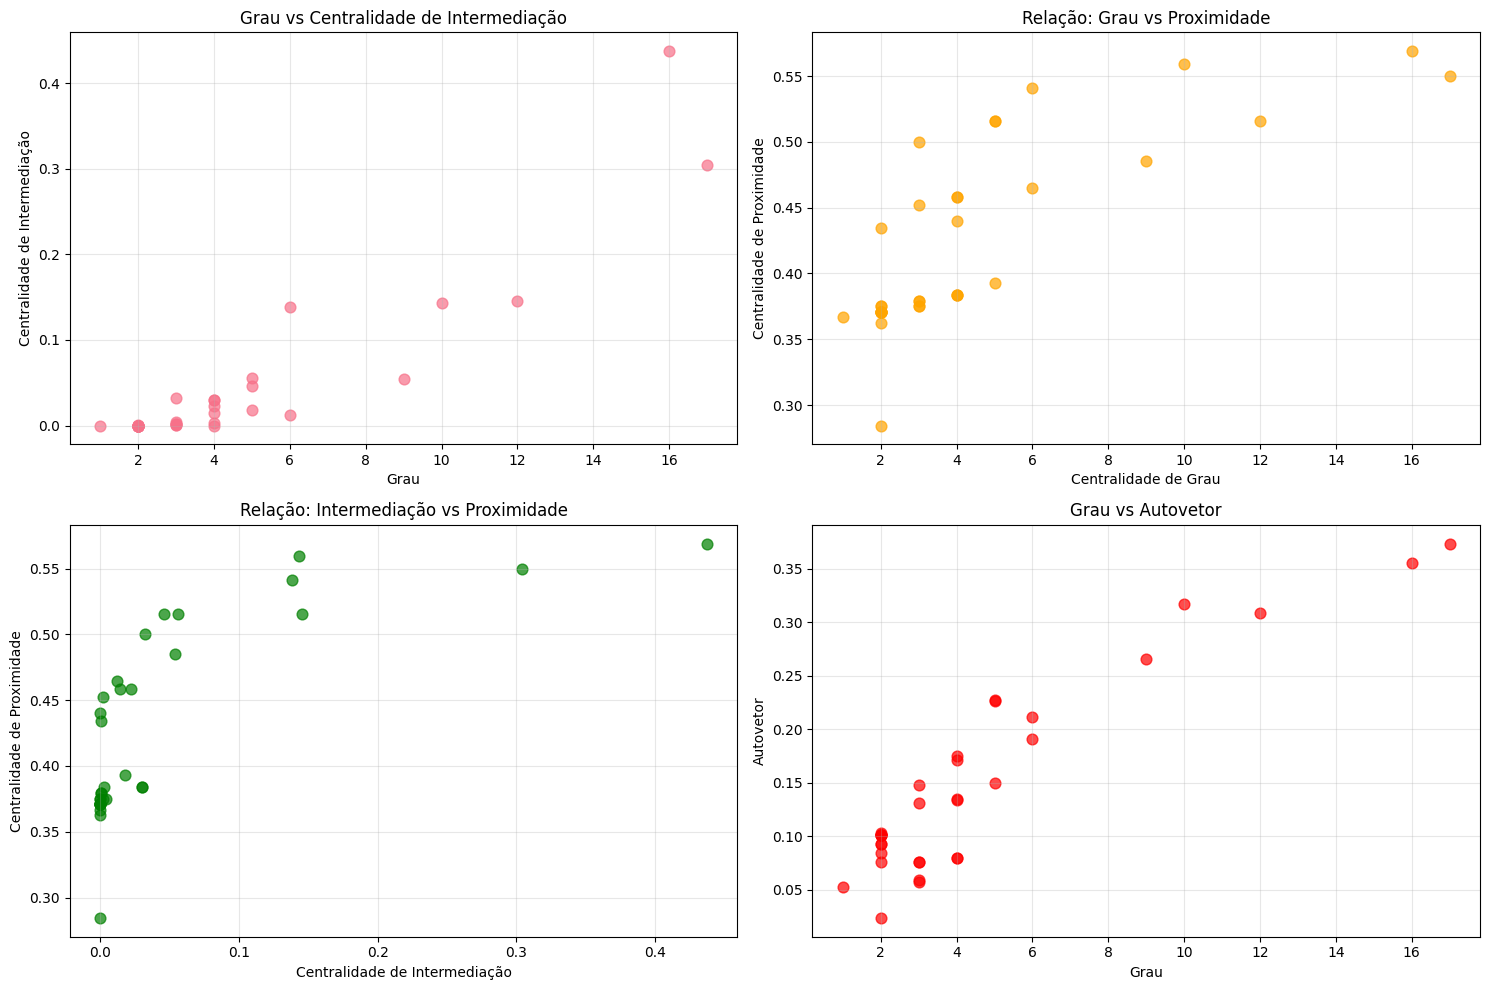

In [139]:
# =============================================================================
# 19. GRÁFICO 18: COMPARAÇÃO ENTRE CENTRALIDADES
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Scatter: Degree vs Betweenness
scatter1 = axes[0].scatter(degrees_list, betweenness_list, alpha=0.7, s=60)
axes[0].set_xlabel ('Grau')
axes[0].set_ylabel ('Centralidade de Intermediação')
axes[0].set_title ('Grau vs Centralidade de Intermediação')
axes[0].grid(True, alpha=0.3)

# Scatter: Degree vs Closeness
scatter2 = axes[1].scatter(degrees_list, list(closeness_centrality.values()), alpha=0.7, s=60, color='orange')
axes[1].set_xlabel ('Centralidade de Grau')
axes[1].set_ylabel ('Centralidade de Proximidade')
axes[1].set_title ('Relação: Grau vs Proximidade')
axes[1].grid(True, alpha=0.3)

# Scatter: Betweenness vs Closeness
scatter3 = axes[2].scatter(betweenness_list, list(closeness_centrality.values()), alpha=0.7, s=60, color='green')
axes[2].set_xlabel ('Centralidade de Intermediação')
axes[2].set_ylabel ('Centralidade de Proximidade')
axes[2].set_title ('Relação: Intermediação vs Proximidade')
axes[2].grid(True, alpha=0.3)

# Scatter: Degree vs Eigenvector
scatter4 = axes[3].scatter(degrees_list, list(eigenvector_centrality.values()), alpha=0.7, s=60, color='red')
axes[3].set_xlabel('Grau')
axes[3].set_ylabel('Autovetor')
axes[3].set_title('Grau vs Autovetor')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_IMAGEM + "PaineisResultados.png", format="PNG")
plt.show ()


In [140]:
# =============================================================================
# 20. RESUMO ESTATÍSTICO
# =============================================================================

print ("# =============================================================================")
print ("# RESUMO ESTATÍSTICO DO GRAFO")
print ("# =============================================================================")
print (f"# Número de nós ......: {G.number_of_nodes()}")
print (f"# Número de arestas ..: {G.number_of_edges()}")
print (f"# Densidade ..........: {nx.density(G):.4f}")
print (f"# Diâmetro ...........: {nx.diameter(G)}")
print (f"# Raio ...............: {nx.radius(G)}")
print (f"# Distância média ....: {nx.average_shortest_path_length(G):.4f}")
print ("# =============================================================================")

print ("\n")
print ("# =============================================================================")
print ("# CENTRALIDADES (MÉDIA)")
print ("# =============================================================================")
print (f"# Betweenness ....: {np.mean(list(betweenness.values())):.4f}")
print (f"# Degree .........: {np.mean(list(degree_centrality.values())):.4f}")
print (f"# Closeness ......: {np.mean(list(closeness_centrality.values())):.4f}")
print (f"# Eigenvector ....: {np.mean(list(eigenvector_centrality.values())):.4f}")
print ("# =============================================================================")

print ("\n")
print ("# =============================================================================")
print ("# NÓS MAIS IMPORTANTES")
print ("# =============================================================================")

max_degree_node = max(degree_dict, key=degree_dict.get)
max_betweenness_node = max(betweenness, key=betweenness.get)
max_closeness_node = max(closeness_centrality, key=closeness_centrality.get)

print (f"# Maior grau .........: Nó {max_degree_node} (grau {degree_dict[max_degree_node]})")
print (f"# Maior betweenness ..: Nó {max_betweenness_node} ({betweenness[max_betweenness_node]:.4f})")
print (f"# Maior closeness ....: Nó {max_closeness_node} ({closeness_centrality[max_closeness_node]:.4f})")
print ("# =============================================================================")

print ("\n")
print ("# =============================================================================")
print ("# ESTRUTURA DE COMUNIDADES")
print ("# =============================================================================")
print (f"# Número de comunidades ....: {len(communities)}")
print (f"# Modularidade .............: {community.modularity(G, communities):.4f}")
community_sizes = [len(com) for com in communities]
print (f"# Tamanho das comunidades ..: {community_sizes}")
print ("# =============================================================================")

print ("\n")
print ("# =============================================================================")
print ("# COEFICIENTE DE AGRUPAMENTO")
print ("# =============================================================================")
print (f"# Coeficiente médio .........: {nx.average_clustering(G):.4f}")
print (f"# Nó com maior clustering ...: {max_cluster_node} ({clustering[max_cluster_node]:.4f})")
print ("# =============================================================================")
 

# =============================================================================
# RESUMO ESTATÍSTICO DO GRAFO
# =============================================================================
# Número de nós ......: 34
# Número de arestas ..: 78
# Densidade ..........: 0.1390
# Diâmetro ...........: 5
# Raio ...............: 3
# Distância média ....: 2.4082
# =============================================================================


# =============================================================================
# CENTRALIDADES (MÉDIA)
# =============================================================================
# Betweenness ....: 0.0440
# Degree .........: 0.1390
# Closeness ......: 0.4265
# Eigenvector ....: 0.1464
# =============================================================================


# =============================================================================
# NÓS MAIS IMPORTANTES
# =============================================================================
# M

In [141]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================